# Notebook 14: Two-Phase Model — Multiclass/Ordinal Evaluation

This notebook evaluates the two-phase model's performance on the 5-class DR grading task (Grades 0-4).
It uses probability predictions and optimal ordinal thresholds to map probabilities to DR severity grades.

In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

BASE_DIR = '.'
FIGURES_DIR = f'{BASE_DIR}/figures'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Setup complete. Loading data...")

Setup complete. Loading data...


## 1. Load Data

Load APTOS test predictions with actual DR grades.

In [5]:
try:
    predictions_df = pd.read_csv(f'{BASE_DIR}/evaluation/aptos_comprehensive/test_predictions_full.csv')
    print(f"Loaded predictions: {predictions_df.shape[0]} samples")
    print(f"\nDR Grade distribution:")
    print(predictions_df['dr_grade'].value_counts().sort_index())
except FileNotFoundError:
    print("ERROR: test_predictions_full.csv not found")
    predictions_df = None

Loaded predictions: 531 samples

DR Grade distribution:
dr_grade
0    270
1     58
2    144
3     22
4     37
Name: count, dtype: int64


## 2. Load Ordinal Configuration

Load optimal ordinal thresholds from evaluation metrics JSON.

In [7]:
try:
    with open(f'{BASE_DIR}/evaluation/aptos_comprehensive/comprehensive_eval_v2.json', 'r') as f:
        eval_data = json.load(f)
    
    ordinal_config = eval_data['ordinal_grading']['twophase_tta']
    thresholds = ordinal_config['thresholds']
    qwk = ordinal_config['qwk']
    accuracy_5class = ordinal_config['accuracy_5class']
    
    print(f"Loaded ordinal configuration for Two-Phase (TTA)")
    print(f"\nThresholds:")
    print(f"  t1 (Grade 0→1): {thresholds['t1']:.6f}")
    print(f"  t2 (Grade 1→2): {thresholds['t2']:.6f}")
    print(f"  t3 (Grade 2→3): {thresholds['t3']:.6f}")
    print(f"  t4 (Grade 3→4): {thresholds['t4']:.6f}")
    print(f"\nMetrics:")
    print(f"  Quadratic Weighted Kappa: {qwk:.4f}")
    print(f"  5-Class Accuracy: {accuracy_5class:.4f}")
except FileNotFoundError:
    print("ERROR: comprehensive_eval_v2.json not found")
    eval_data = None
except KeyError:
    print("ERROR: ordinal configuration not found in eval data")
    eval_data = None

Loaded ordinal configuration for Two-Phase (TTA)

Thresholds:
  t1 (Grade 0→1): 0.310700
  t2 (Grade 1→2): 0.757900
  t3 (Grade 2→3): 0.995400
  t4 (Grade 3→4): 0.999000

Metrics:
  Quadratic Weighted Kappa: 0.7147
  5-Class Accuracy: 0.5970


## 3. Apply Ordinal Thresholds

Map predicted probabilities to 5-class grades using the optimal thresholds.

In [9]:
def apply_ordinal_thresholds(probabilities, thresholds_dict):
    """
    Convert probabilities to ordinal grades (0-4) using thresholds.
    prob < t1 → Grade 0
    t1 ≤ prob < t2 → Grade 1
    t2 ≤ prob < t3 → Grade 2
    t3 ≤ prob < t4 → Grade 3
    prob ≥ t4 → Grade 4
    """
    t1, t2, t3, t4 = (thresholds_dict['t1'], thresholds_dict['t2'], 
                      thresholds_dict['t3'], thresholds_dict['t4'])
    
    grades = np.zeros_like(probabilities, dtype=int)
    grades[(probabilities >= t1) & (probabilities < t2)] = 1
    grades[(probabilities >= t2) & (probabilities < t3)] = 2
    grades[(probabilities >= t3) & (probabilities < t4)] = 3
    grades[probabilities >= t4] = 4
    
    return grades

if predictions_df is not None and eval_data is not None:
    y_true_grade = predictions_df['dr_grade'].values
    prob_tta = predictions_df['prob_twophase_TTA'].values
    
    y_pred_grade = apply_ordinal_thresholds(prob_tta, thresholds)
    
    print(f"\nPredicted grade distribution:")
    unique, counts = np.unique(y_pred_grade, return_counts=True)
    for g, c in zip(unique, counts):
        print(f"  Grade {g}: {c} ({c/len(y_pred_grade)*100:.1f}%)")


Predicted grade distribution:
  Grade 0: 268 (50.5%)
  Grade 1: 8 (1.5%)
  Grade 2: 37 (7.0%)
  Grade 3: 15 (2.8%)
  Grade 4: 203 (38.2%)


## 4. 5-Class Confusion Matrix

5x5 heatmap showing multiclass prediction accuracy.

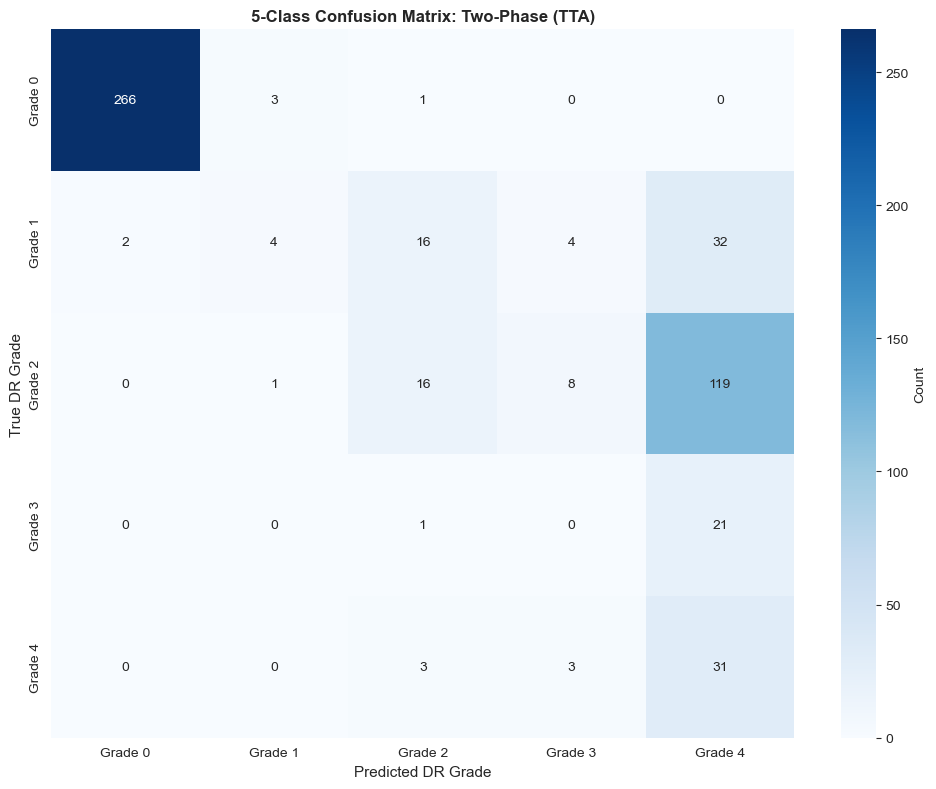

In [11]:
if predictions_df is not None and eval_data is not None:
    cm = confusion_matrix(y_true_grade, y_pred_grade, labels=[0, 1, 2, 3, 4])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'],
                yticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'],
                cbar_kws={'label': 'Count'})
    
    ax.set_title('5-Class Confusion Matrix: Two-Phase (TTA)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True DR Grade', fontsize=11)
    ax.set_xlabel('Predicted DR Grade', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/14_confusion_matrix_5class.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Per-Class Metrics

Precision, recall, and F1-score for each DR grade.

In [13]:
if predictions_df is not None and eval_data is not None:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_grade, y_pred_grade, labels=[0, 1, 2, 3, 4], zero_division=0
    )
    
    metrics_df = pd.DataFrame({
        'Grade': ['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'],
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Support': support
    })
    
    print("\n" + "="*70)
    print("PER-CLASS METRICS")
    print("="*70)
    print(metrics_df.to_string(index=False))
    print("="*70)


PER-CLASS METRICS
  Grade  Precision   Recall  F1-Score  Support
Grade 0   0.992537 0.985185  0.988848      270
Grade 1   0.500000 0.068966  0.121212       58
Grade 2   0.432432 0.111111  0.176796      144
Grade 3   0.000000 0.000000  0.000000       22
Grade 4   0.152709 0.837838  0.258333       37


## 6. Quadratic Weighted Kappa

Compute Cohen's quadratic weighted kappa, which accounts for ordinal nature of grades.

In [15]:
def quadratic_weighted_kappa(y_true, y_pred):
    """
    Calculate quadratic weighted kappa for ordinal classification.
    """
    from sklearn.metrics import cohen_kappa_score
    # For ordinal data, we can use the standard cohen_kappa_score
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

if predictions_df is not None and eval_data is not None:
    qwk_computed = quadratic_weighted_kappa(y_true_grade, y_pred_grade)
    
    print(f"\nQuadratic Weighted Kappa:")
    print(f"  Computed: {qwk_computed:.6f}")
    print(f"  Expected (from config): {qwk:.6f}")
    print(f"\nInterpretation:")
    if qwk_computed >= 0.8:
        print(f"  Excellent agreement (≥0.80)")
    elif qwk_computed >= 0.6:
        print(f"  Substantial agreement (0.60-0.79)")
    elif qwk_computed >= 0.4:
        print(f"  Moderate agreement (0.40-0.59)")
    else:
        print(f"  Fair agreement (<0.40)")


Quadratic Weighted Kappa:
  Computed: 0.714663
  Expected (from config): 0.714700

Interpretation:
  Substantial agreement (0.60-0.79)


## 7. Grade Distribution

Compare true vs predicted grade distributions.

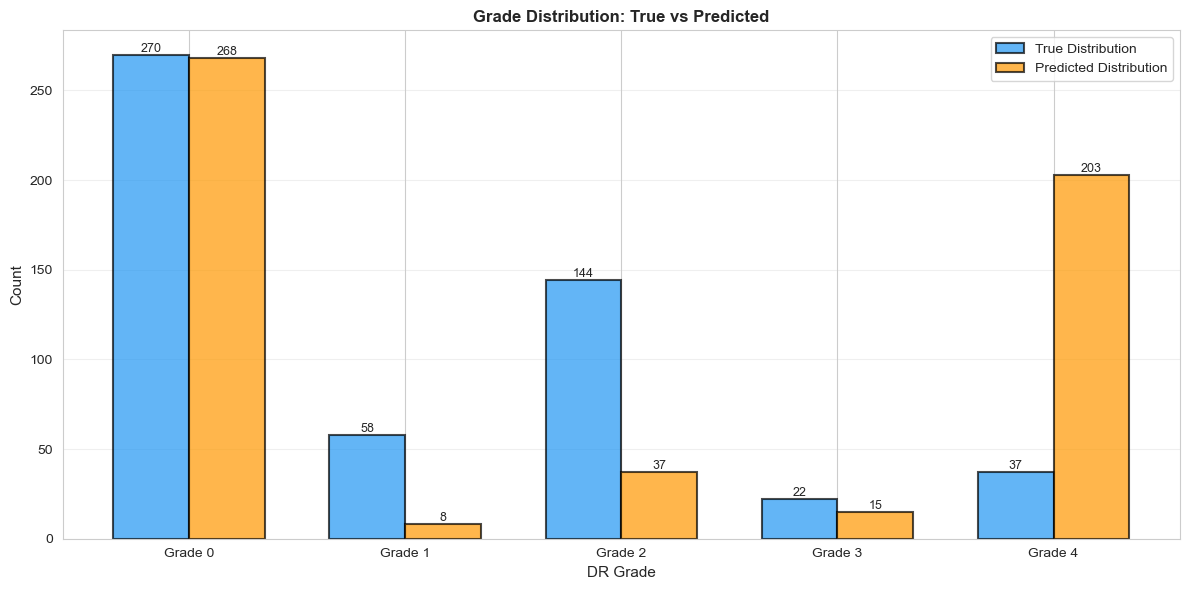

In [17]:
if predictions_df is not None:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    x = np.arange(5)
    width = 0.35
    
    true_counts = np.array([sum(y_true_grade == i) for i in range(5)])
    pred_counts = np.array([sum(y_pred_grade == i) for i in range(5)])
    
    bars1 = ax.bar(x - width/2, true_counts, width, label='True Distribution',
                   color='#2196F3', alpha=0.7, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, pred_counts, width, label='Predicted Distribution',
                   color='#FF9800', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('DR Grade', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title('Grade Distribution: True vs Predicted', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Grade {i}' for i in range(5)])
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/14_grade_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Probability Distribution by True Grade

Violin plots showing predicted probability distributions grouped by true DR grade.

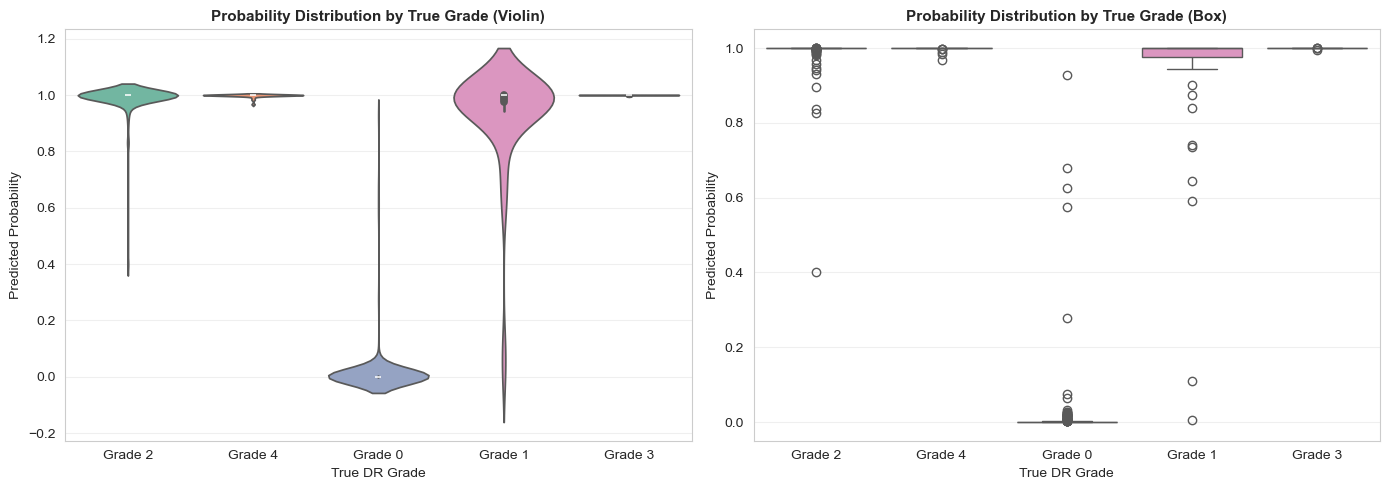

In [19]:
if predictions_df is not None:
    # Create dataframe for plotting
    plot_df = pd.DataFrame({
        'True Grade': [f'Grade {g}' for g in y_true_grade],
        'Predicted Probability': prob_tta
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Violin plot
    sns.violinplot(data=plot_df, x='True Grade', y='Predicted Probability', ax=axes[0],
                   palette='Set2', inner='box')
    axes[0].set_title('Probability Distribution by True Grade (Violin)', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Predicted Probability', fontsize=10)
    axes[0].set_xlabel('True DR Grade', fontsize=10)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Box plot
    sns.boxplot(data=plot_df, x='True Grade', y='Predicted Probability', ax=axes[1],
               palette='Set2')
    axes[1].set_title('Probability Distribution by True Grade (Box)', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Predicted Probability', fontsize=10)
    axes[1].set_xlabel('True DR Grade', fontsize=10)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/14_probability_by_grade.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9. Per-Grade Accuracy

Classification accuracy for each DR grade.

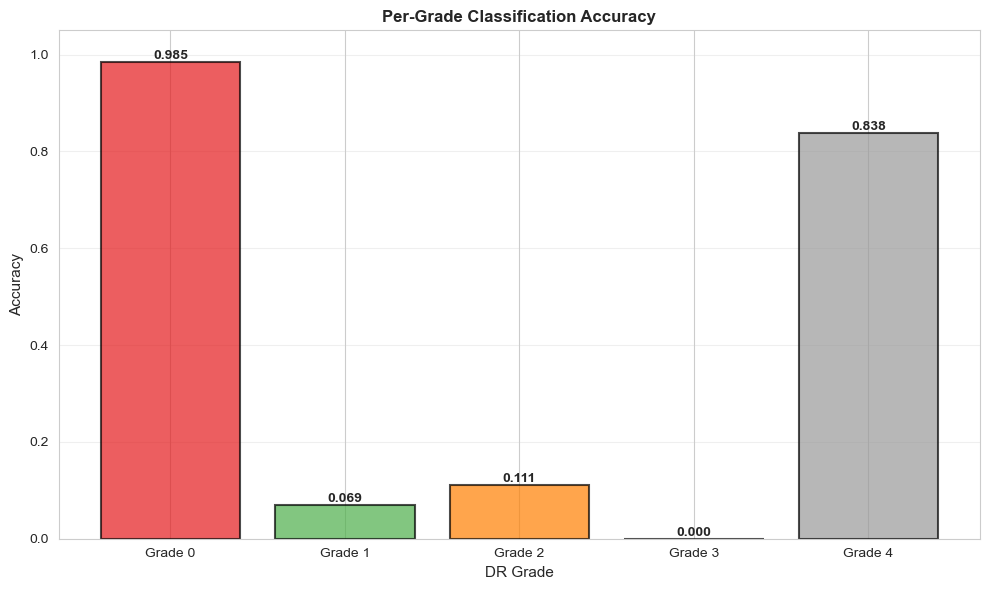


Per-Grade Accuracy:
  Grade 0: 0.9852
  Grade 1: 0.0690
  Grade 2: 0.1111
  Grade 3: 0.0000
  Grade 4: 0.8378


In [21]:
if predictions_df is not None:
    grade_accuracies = []
    
    for grade in range(5):
        mask = y_true_grade == grade
        if mask.sum() > 0:
            acc = (y_pred_grade[mask] == y_true_grade[mask]).mean()
            grade_accuracies.append(acc)
        else:
            grade_accuracies.append(0)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    colors = plt.cm.Set1(np.linspace(0, 1, 5))
    bars = ax.bar([f'Grade {i}' for i in range(5)], grade_accuracies,
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels
    for bar, acc in zip(bars, grade_accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{acc:.3f}',
               ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_xlabel('DR Grade', fontsize=11)
    ax.set_title('Per-Grade Classification Accuracy', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/14_per_grade_accuracy.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nPer-Grade Accuracy:")
    for i, acc in enumerate(grade_accuracies):
        print(f"  Grade {i}: {acc:.4f}")

## 10. Misclassification Analysis

Analyze which grades get confused most frequently.

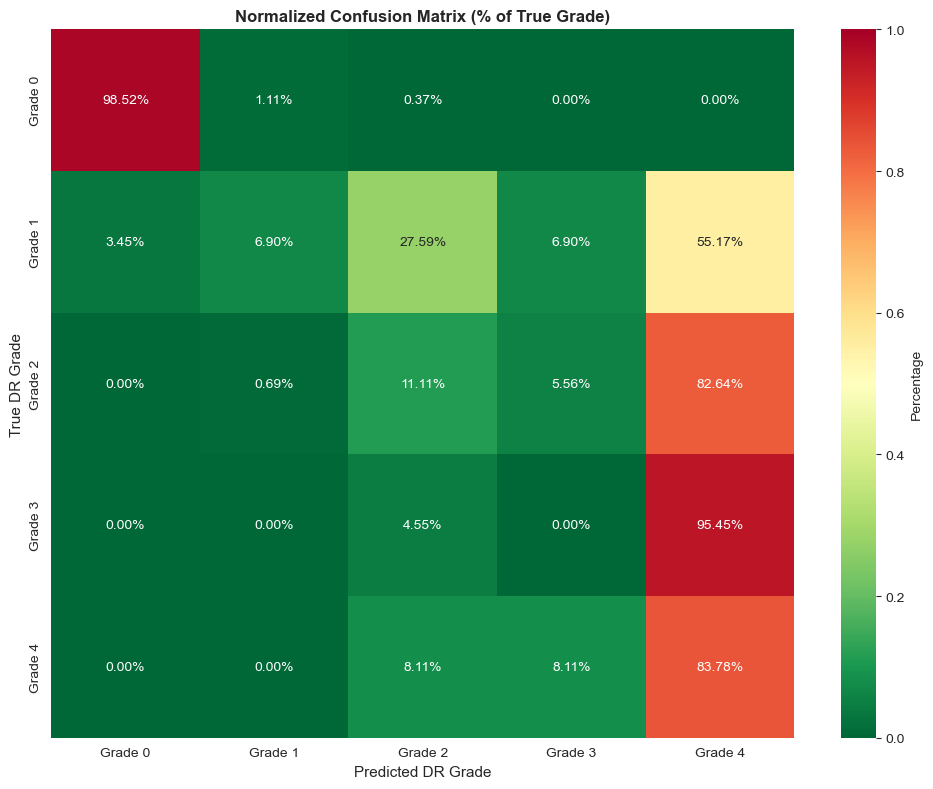


Most common misclassification pairs (True Grade → Predicted Grade):
  Grade 2 → Grade 4: 119 cases
  Grade 1 → Grade 4: 32 cases
  Grade 3 → Grade 4: 21 cases
  Grade 1 → Grade 2: 16 cases
  Grade 2 → Grade 3: 8 cases
  Grade 1 → Grade 3: 4 cases
  Grade 0 → Grade 1: 3 cases
  Grade 4 → Grade 2: 3 cases
  Grade 4 → Grade 3: 3 cases
  Grade 1 → Grade 0: 2 cases


In [23]:
if predictions_df is not None:
    # Normalized confusion matrix (percentage)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=ax,
                xticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'],
                yticklabels=['Grade 0', 'Grade 1', 'Grade 2', 'Grade 3', 'Grade 4'],
                cbar_kws={'label': 'Percentage'},
                vmin=0, vmax=1)
    
    ax.set_title('Normalized Confusion Matrix (% of True Grade)', fontsize=12, fontweight='bold')
    ax.set_ylabel('True DR Grade', fontsize=11)
    ax.set_xlabel('Predicted DR Grade', fontsize=11)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/14_confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print grade confusion pairs
    print("\nMost common misclassification pairs (True Grade → Predicted Grade):")
    misclass_list = []
    for i in range(5):
        for j in range(5):
            if i != j and cm[i, j] > 0:
                misclass_list.append((i, j, cm[i, j]))
    
    misclass_list.sort(key=lambda x: x[2], reverse=True)
    for true_grade, pred_grade, count in misclass_list[:10]:
        print(f"  Grade {true_grade} → Grade {pred_grade}: {count} cases")

## 11. Ordinal Error Distribution

Analyze prediction errors as differences in severity grades (off-by-N).

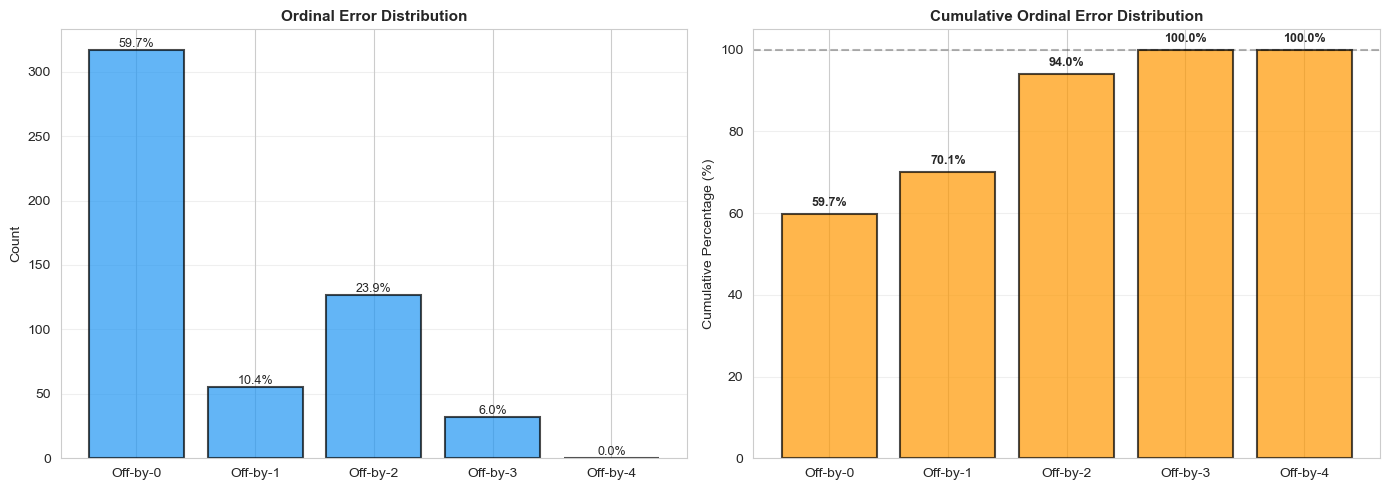


Ordinal Error Distribution:
  Off-by-0: 317 (59.70%)
  Off-by-1: 55 (10.36%)
  Off-by-2: 127 (23.92%)
  Off-by-3: 32 (6.03%)
  Off-by-4: 0 (0.00%)

Summary:
  Exact predictions (off-by-0): 317 (59.70%)
  Within ±1 grade: 70.06%
  Mean absolute error: 0.7627 grades


In [37]:
if predictions_df is not None:
    errors = np.abs(y_true_grade - y_pred_grade)
    
    error_dist = {}
    for e in range(5):
        count = (errors == e).sum()
        error_dist[f'Off-by-{e}'] = count
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot
    ax = axes[0]
    labels = list(error_dist.keys())
    counts = list(error_dist.values())
    percentages = [c / len(errors) * 100 for c in counts]
    
    bars = ax.bar(labels, counts, color='#2196F3', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title('Ordinal Error Distribution', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    for bar, pct in zip(bars, percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{pct:.1f}%',
               ha='center', va='bottom', fontsize=9)
    
    # Cumulative plot
    ax = axes[1]
    cumsum = np.cumsum(counts)
    cumsum_pct = cumsum / len(errors) * 100
    
    ax.bar(labels, cumsum_pct, color='#FF9800', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=100, color='k', linestyle='--', alpha=0.3)
    ax.set_ylabel('Cumulative Percentage (%)', fontsize=10)
    ax.set_title('Cumulative Ordinal Error Distribution', fontsize=11, fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(True, alpha=0.3, axis='y')
    
    for i, (label, pct) in enumerate(zip(labels, cumsum_pct)):
        ax.text(i, pct + 2, f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/14_ordinal_error_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nOrdinal Error Distribution:")
    for err, count in error_dist.items():
        pct = count / len(errors) * 100
        print(f"  {err}: {count} ({pct:.2f}%)")
    
    print(f"\nSummary:")
    print(f"  Exact predictions (off-by-0): {error_dist['Off-by-0']} ({error_dist['Off-by-0']/len(errors)*100:.2f}%)")
    print(f"  Within ±1 grade: {(error_dist['Off-by-0'] + error_dist['Off-by-1'])/len(errors)*100:.2f}%")
    print(f"  Mean absolute error: {errors.mean():.4f} grades")